In [1]:
import matplotlib.pyplot as plt
import numpy as np
import csv
import scipy
from scipy.signal import find_peaks

plt.style.use('moje.mplstyle')

In [ ]:
UR = np.genfromtxt(r'S:\1.FILE\eqn\eqn-ur-ok.csv', delimiter=',', skip_header=1)

t = UR[: , 0]/1e6
u = UR[: , 1]/50
r = UR[: , 2]/1e3

In [3]:
ABR = np.genfromtxt(r'S:\1.FILE\eqn\eqn-ab-new.csv', delimiter=',', skip_header=1)

tt = ABR[: , 0]/1e6
a = ABR[: , 1]/1e3
b = ABR[: , 2]/1e3

In [4]:
try:
  def pnej(seznam):
    peaks, _ = find_peaks(-seznam, height=-0.01)
    indexy = t[peaks[0]]
    return indexy                
except IndexError:
  R = 50

R = pnej(r)

def timel(leng,okno,jaky):
    if jaky == "R":
        jaky = R

    N1 = np.linspace(jaky-(-1 * ((leng-1) /2)) * okno , jaky-((leng-1) /2)* okno,leng)
    N2 = np.linspace(-1 * ((leng-1) /2) * okno , ((leng-1) /2) * okno,leng)
    N1 = N1.tolist()
    N1.sort()
    N2 = N2.tolist()
    N2 = ["%.2f" % member for member in N2]

    return(N1,N2)

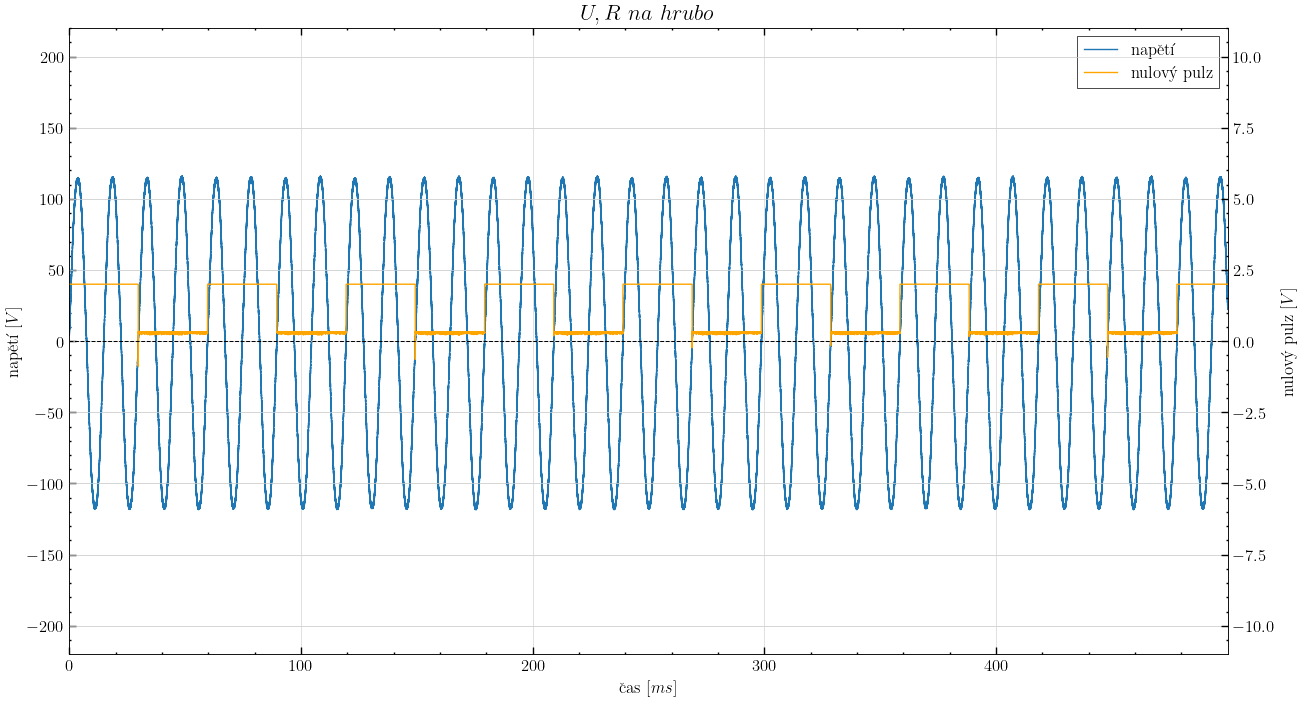

In [5]:
fig, host = plt.subplots(figsize=(13,7), layout='constrained')
ax2 = host.twinx()  
host.set_xlim(0, t[-1])
host.set_ylim(-220, 220)
ax2.set_ylim(-11, 11)

host.set_xlabel("čas $[ms]$", fontsize=12)
host.set_ylabel("napětí $[V]$", fontsize=12)
ax2.set_ylabel("nulový pulz $[V]$", fontsize=12)

p1 = host.plot(t, u, label="napětí")
p2 = ax2.plot(t, r, label="nulový pulz", color='orange')

plt.hlines(0.00075/2,0, t[-1], color = 'k', linestyles='--',lw = 0.75)

# plt.title("U,R na hrubo")
plt.title(r"$U,R$ $na$ $hrubo$", fontsize=16, color='k')
host.legend(handles=p1+p2, loc='upper right')
# host.set_yticks(np.arange(-120, 140, step=40))
host.yaxis.label.set_color(p1[0].get_color())
ax2.yaxis.label.set_color(p2[0].get_color())
# host.grid(color='lightgrey', linestyle='-', linewidth=0.5)
host.set_xlabel("čas $[ms]$", fontsize=12, color = 'k')
host.set_ylabel("napětí $[V]$", fontsize=12, color = 'k')
ax2.set_ylabel("nulový pulz $[V]$", fontsize=12, color = 'k')
# ax = plt.gca()
# ax.spines['bottom'].set_color('k')
# ax.spines['top'].set_color('k') 
# ax.spines['right'].set_color(p2[0].get_color())
# ax.spines['left'].set_color(p1[0].get_color())

plt.savefig("eqn_ur-h.png")

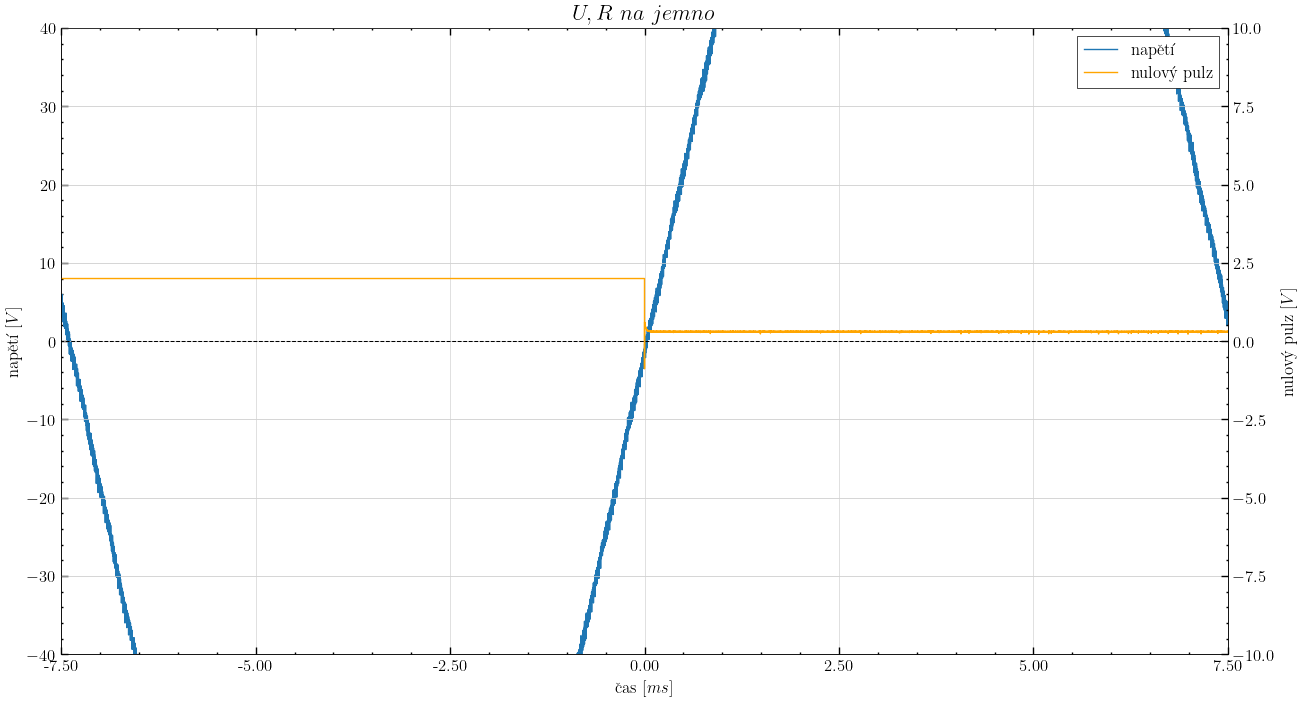

In [6]:
fig, host = plt.subplots(figsize=(13,7), layout='constrained')
ax2 = host.twinx()
ax = plt.gca()
    
host.set_xlim(R-7.5, R+7.5)
host.set_ylim(-40, 40)
ax2.set_ylim(-10, 10)

p1 = host.plot(t, u, label="napětí")
p2 = ax2.plot(t, r, label="nulový pulz", color='orange')
# ax2.set_yticks(np.arange(-0.5, 0.5+0.5/4, step=0.5/4))
plt.hlines(0,0,t[-1],color = 'k', linestyles='--',lw = 0.75)
plt.title("$U,R$ $na$ $jemno$", fontsize=16, color='k')
host.legend(handles=p1+p2, loc='upper right')
host.set_yticks(np.arange(-40, 50, step=10))
host.yaxis.label.set_color(p1[0].get_color())
ax2.yaxis.label.set_color(p2[0].get_color())


# ax.set_xticks([R,R-0.2,R+0.2,R-0.4,R+0.4,R-0.6,R+0.6]) 
# ax.set_xticklabels(['0',"-0.2","0.2","-0.4","0.4","-0.6","0.6"])
N1 , N2 = timel(7,2.5,"R")
ax.set_xticks(N1) 
ax.set_xticklabels(N2)
host.set_xlabel("čas $[ms]$", fontsize=12, color = 'k')
host.set_ylabel("napětí $[V]$", fontsize=12, color = 'k')
ax2.set_ylabel("nulový pulz $[V]$", fontsize=12, color = 'k')
# plt.show()
plt.savefig("eqn_ur.png")

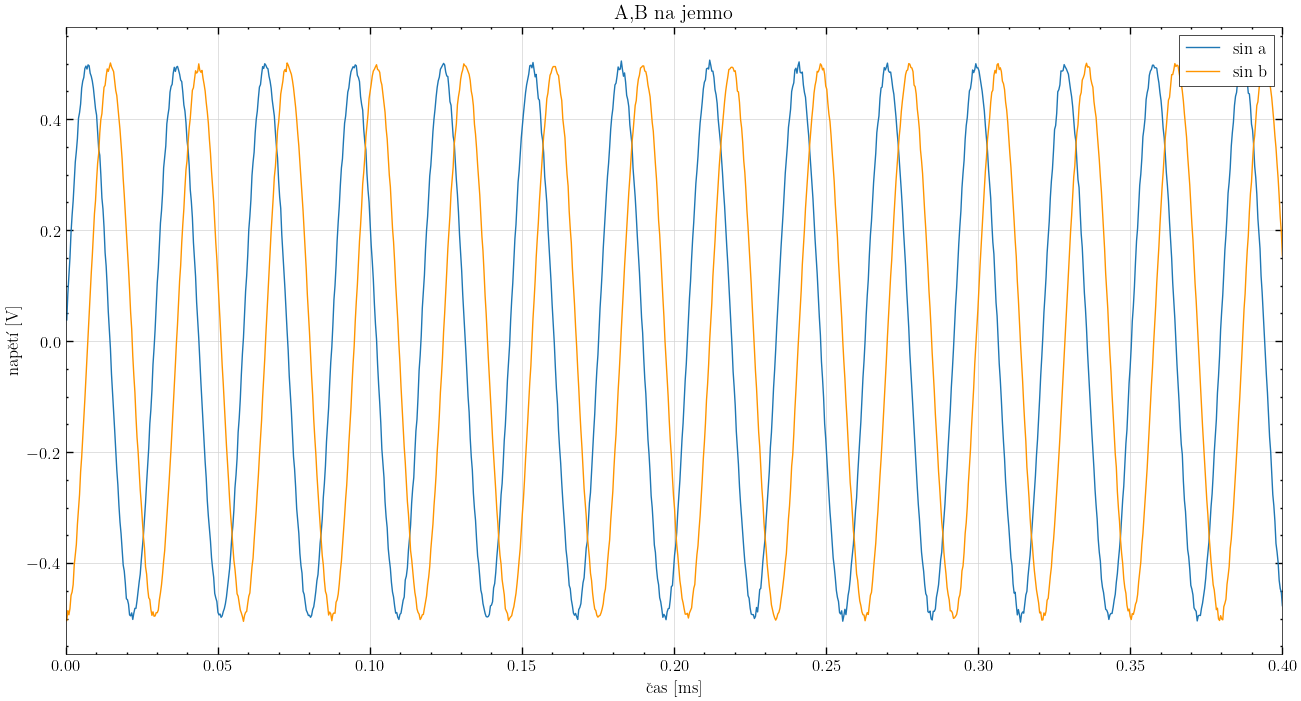

In [7]:
fig, host = plt.subplots(figsize=(13,7), layout='constrained')
ax = plt.gca()
plt.title("A,B na jemno")
p1 = plt.plot(tt,a, label="sin a")
p2 = plt.plot(tt,b, label="sin b")
plt.xlim(0,0.4)
host.set_xlabel("čas [ms]")
host.set_ylabel("napětí [V]")
host.legend(handles=p1+p2, loc='upper right')
plt.grid(color='lightgrey', linestyle='-', linewidth=0.5)
# # plt.show()
# ax.set_xticks([RR,RR-0.2,RR+0.2,RR-0.1,RR+0.1])#,RR-0.4,RR+0.4,RR-0.6,RR+0.6]) 
# ax.set_xticklabels(['0',"-0.2","0.2","-0.1","0.1"])#,"-0.4","+0.4","-0.6","+0.6"])
# ax.set_xticks(N1) 
# ax.set_xticklabels(N2)

# plt.show()
plt.savefig("eqn_ab.png")

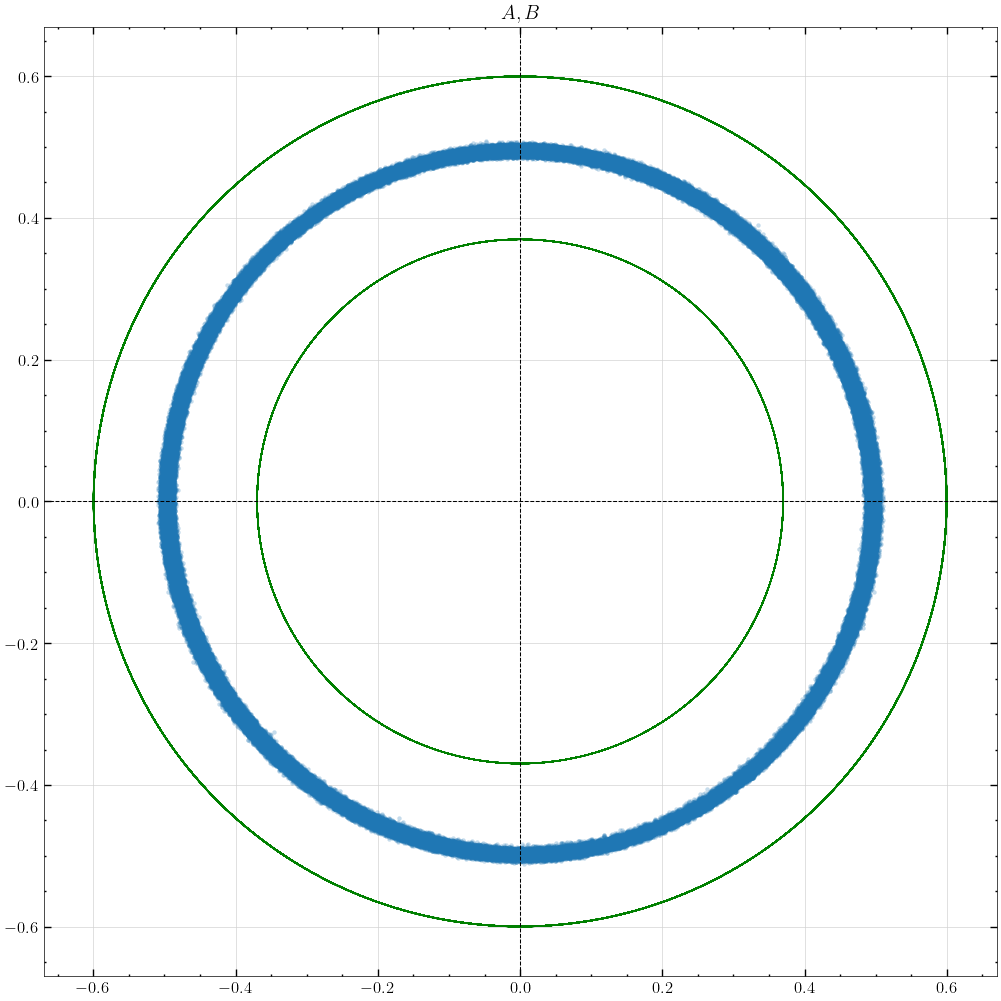

In [8]:
x = np.linspace(0,1000,10000)
y = 0.6 *np.sin(1*x+0)+0
yy = 0.6 *np.sin(1*x+np.pi/2)+0
w = 0.37 *np.sin(1*x+0)+0
ww = 0.37 *np.sin(1*x+np.pi/2)+0
fig = plt.subplots(figsize=(10,10), layout='constrained')
plt.title("$A,B$")
plt.plot(y,yy, lw = 0.75,color = 'g')
plt.plot(w,ww, lw = 0.75,color = 'g')
# plt.scatter(a,b, linewidths= 0.1, marker=".", alpha=0.005)
plt.scatter(a[0:len(a)//6],b[0:len(b)//6], linewidths= 0.1, marker=".", alpha=0.25)
plt.xlim(-0.67,0.67)
plt.ylim(-0.67,0.67)
plt.vlines(0,-0.67,0.67,color = 'k', linestyles='--',lw = 0.75)
plt.hlines(0,-0.67,0.67,color = 'k', linestyles='--',lw = 0.75)
plt.savefig("eqn_kola.png")
# plt.show()

Změřená frekvence signálu: 34258.03 Hz


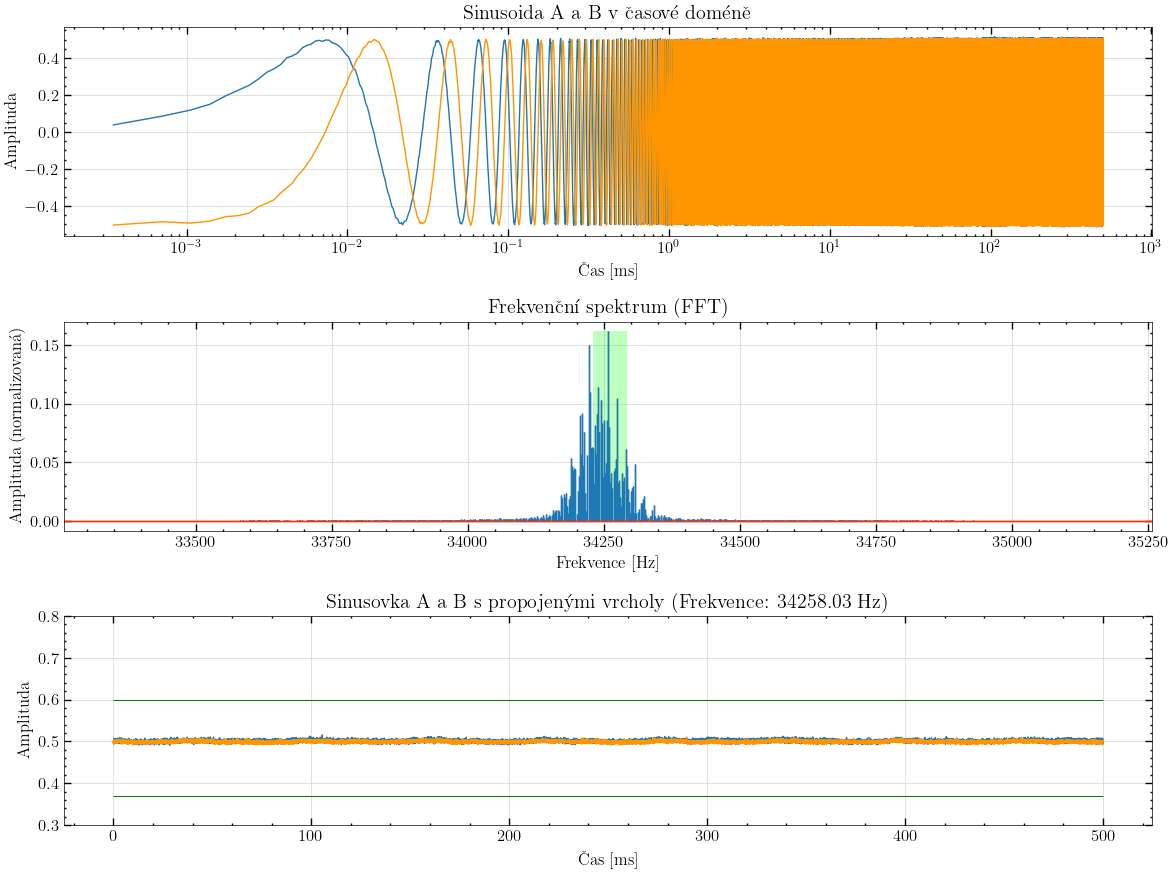

In [9]:
import numpy as np
from scipy.fft import fft, fftfreq
import matplotlib.pyplot as plt


def propoj_vrcholy_sinusovky(frekvence, vzorkovaci_frekvence, sinusoida, casova_osa):
    min_vzdalenost_mezi_vrcholy = int(vzorkovaci_frekvence / frekvence * 0.8) # 0.8 pro jistotu
    vrcholy_indexy, _ = find_peaks(sinusoida, distance=min_vzdalenost_mezi_vrcholy)
    # Získání hodnot časové osy a amplitudy pro nalezené vrcholy
    cas_vrcholu = casova_osa[vrcholy_indexy]
    amplituda_vrcholu = sinusoida[vrcholy_indexy]
    return cas_vrcholu, amplituda_vrcholu

def measure_frequency_of_sine_wave(signal_data, sample_rate):

    N = len(signal_data)  # Počet vzorků
    yf = fft(signal_data) # Provede rychlou Fourierovu transformaci
    xf = fftfreq(N, 1 / sample_rate) # Vypočítá frekvenční osy

    # Vezmeme pouze kladné frekvence (spektrum je symetrické)
    # Ignorujeme frekvenci 0 Hz (stejnosměrnou složku)
    positive_freq_indices = np.where(xf > 0)
    xf_positive = xf[positive_freq_indices]
    yf_positive = np.abs(yf[positive_freq_indices])

    # Najdeme index frekvence s největší amplitudou
    dominant_frequency_index = np.argmax(yf_positive)
    dominant_frequency = xf_positive[dominant_frequency_index]

    return dominant_frequency

# Výpočet frekvence

sample_rate = 1/350e-9  # Vzorkovací frekvence v Hz (např. 1000 vzorků za sekundu)
duration = tt[-1]      # Doba trvání signálu v sekundách

# --- Měření frekvence ---
measured_freq = measure_frequency_of_sine_wave(a, sample_rate)
print(f"Změřená frekvence signálu: {measured_freq:.2f} Hz")
cas_vrcholu, amplituda_vrcholu = propoj_vrcholy_sinusovky(measured_freq, sample_rate, a, tt)
cas_vrcholu_b, amplituda_vrcholu_b = propoj_vrcholy_sinusovky(measured_freq, sample_rate, b, tt)


# --- Volitelná vizualizace ---

plt.figure(figsize=(12, 9))
plt.subplot(3, 1, 1)
plt.plot(tt,a, label="sin A")
plt.plot(tt, b, label="sin B")
plt.title('Sinusoida A a B v časové doméně')
plt.xlabel('Čas [ms]')
plt.ylabel('Amplituda')
plt.grid(True)
plt.xscale("log")
#plt.legend(bbox_to_anchor=(0,1,1,.1), ncol=2, mode = "expand", loc = "lower left")

# Zobrazení frekvenčního spektra

Na = len(a)
Ta = 1/sample_rate
yfa = fft(a)
xfa = fftfreq(Na, Ta)[:Na//2]

Nb = len(b)
Tb = 1/sample_rate
yfb = fft(b)
xfb = fftfreq(Nb, Tb)[:Nb//2]

plt.subplot(3, 1, 2)
plt.stem(xfa, 2.0/Na * np.abs(yfa[0:Na//2]),markerfmt="")
plt.stem(xfb, 2.0/Nb * np.abs(yfb[0:Nb//2]),markerfmt="")
plt.title('Frekvenční spektrum (FFT)')
plt.xlabel('Frekvence [Hz]')
plt.ylabel('Amplituda (normalizovaná)')
plt.grid(True)
# plt.xlim(0, measured_freq * 2) # Omezíme zobrazení na zajímavou část spektra
plt.xlim(measured_freq - 1000, measured_freq + 1000) # Omezíme zobrazení na zajímavou část spektra
#plt.vlines((34230.891+34279.019)/2,0,max( 2.0/Na * np.abs(yfa[0:Na//2])),color = 'g',lw = 34230.891-34279.019, alpha=0.25)

import matplotlib.patches as patches
obdelnik = patches.Rectangle((34230, 0), 34292-34230, max( 2.0/Na * np.abs(yfa[0:Na//2])), 
                            edgecolor='none', 
                            facecolor='lime', 
                            alpha=0.25, 
                            linewidth=1)
os = plt.gca()
os.add_patch(obdelnik)
plt.subplot(3, 1, 3)
#plt.plot(tt, a, label='Původní sinusovka')
# Spojení vrcholů čarami
plt.plot(cas_vrcholu, amplituda_vrcholu, label='Spojené vrcholy')
plt.plot(cas_vrcholu_b, amplituda_vrcholu_b, label='Spojené vrcholy')
plt.hlines(0.37,0,cas_vrcholu[-1],color = 'g',lw = 0.75)
plt.hlines(0.6,0,cas_vrcholu[-1],color = 'g',lw = 0.75)
plt.title(f'Sinusovka A a B s propojenými vrcholy (Frekvence: {measured_freq:.2f} Hz)')
plt.xlabel('Čas [ms]')
plt.ylabel('Amplituda')
#plt.legend()
plt.ylim(0.3,0.8)
plt.tight_layout()
plt.show()